# Pose Auto Recurrence Quantification Analysis

## Load Framewise Pose Data

In [ ]:
# %pip install -q ipywidgets
%matplotlib inline

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, SelectMultiple, ToggleButtons, Checkbox, Button, VBox, HBox, Output
from IPython.display import display

# -------------------------------------------------------------------
# Paths (edit if needed)
# -------------------------------------------------------------------
PER_FRAME_ROOT = "data/processed/experimental/features/per_frame"

NORM_MAP = {
    "Original":                 "original",
    "Procrustes (Global)":      "procrustes_global",
    "Procrustes (Participant)": "procrustes_participant",
}

META_COLS = {"participant","condition","frame","interocular"}

COND_ORDER = ["L","M","H"]

# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def scan_files(norm_label: str):
    """Return list of CSV file paths for the chosen normalization."""
    sub = NORM_MAP[norm_label]
    d = os.path.join(PER_FRAME_ROOT, sub)
    if not os.path.isdir(d):
        return []
    return sorted(glob.glob(os.path.join(d, "*.csv")))

def peek_df(path: str, n=5):
    try:
        return pd.read_csv(path, nrows=n)
    except Exception:
        return None

def parse_pid_cond_from_df(df: pd.DataFrame) -> tuple[str|None, str|None]:
    pid = str(df["participant"].iloc[0]) if "participant" in df.columns and len(df) else None
    cond = str(df["condition"].iloc[0]) if "condition" in df.columns and len(df) else None
    return pid, cond

def list_participants_and_conditions(file_paths):
    pids, conds = set(), set()
    for p in file_paths:
        head = peek_df(p, n=1)
        if head is None: 
            continue
        pid, cond = parse_pid_cond_from_df(head)
        if pid is not None: pids.add(pid)
        if cond is not None: conds.add(cond)
    return sorted(pids), sorted(conds, key=lambda c: COND_ORDER.index(c) if c in COND_ORDER else 999)

def candidate_metrics_from_any(file_paths):
    for p in file_paths:
        df = peek_df(p, n=5)
        if df is None: 
            continue
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        # remove meta
        num_cols = [c for c in num_cols if c not in META_COLS]
        if num_cols: 
            # prefer the "core" per-frame features first
            preferred = []
            for key in ["head_rotation_rad","blink_aperture","mouth_aperture","pupil_metric","center_face_magnitude","interocular"]:
                if key in num_cols:
                    preferred.append(key)
            others = [c for c in num_cols if c not in preferred]
            return preferred + sorted(others)
    return []

def load_series(file_paths, metric, condition_filter=None, participant_filter=None):
    """Return list of (pid, cond, series ndarray) for files matching filters."""
    out = []
    for p in file_paths:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        if metric not in df.columns:
            continue

        pid = str(df["participant"].iloc[0]) if "participant" in df.columns and len(df) else None
        cond = str(df["condition"].iloc[0]) if "condition" in df.columns and len(df) else None

        if condition_filter and cond not in condition_filter: 
            continue
        if participant_filter and pid not in participant_filter: 
            continue

        s = pd.to_numeric(df[metric], errors="coerce").to_numpy()
        out.append((pid, cond, s))
    return out

def average_aligned(series_list):
    """Average multiple 1D arrays by truncating to min length and averaging pointwise."""
    if not series_list: 
        return None
    minlen = min(len(s) for s in series_list if len(s) > 0)
    if minlen == 0:
        return None
    stack = np.vstack([s[:minlen] for s in series_list])
    return np.nanmean(stack, axis=0)

# -------------------------------------------------------------------
# Widgets
# -------------------------------------------------------------------
w_norm         = Dropdown(options=list(NORM_MAP.keys()), value="Original", description="Normalization:")
w_condition    = SelectMultiple(options=["(all)","L","M","H"], value=["(all)"], description="Condition:")
w_participant  = SelectMultiple(options=["(scan first)"], value=["(scan first)"], description="Participant:")
w_metric       = Dropdown(options=[], value=None, description="Metric:")
w_avg          = Checkbox(value=False, description="Average across files")
w_load         = Button(description="Load series", button_style="primary")
out_scan       = Output()
out_status     = Output()

def refresh_after_norm_change(*_):
    out_scan.clear_output()
    files = scan_files(w_norm.value)
    pids, conds = list_participants_and_conditions(files)
    if not pids:
        pids = []
    if not conds:
        conds = ["L","M","H"]
    # update participants
    w_participant.options = ["(all)"] + pids
    w_participant.value   = ("(all)",)
    # update conditions
    w_condition.options   = ["(all)"] + conds
    w_condition.value     = ("(all)",)
    # metrics
    mets = candidate_metrics_from_any(files)
    w_metric.options = mets
    w_metric.value   = mets[0] if mets else None
    with out_scan:
        print(f"Found {len(files)} per-frame files in: {os.path.join(PER_FRAME_ROOT, NORM_MAP[w_norm.value])}")
        if pids:
            print(f"Participants: {len(pids)} (e.g., {', '.join(pids[:8])}{'…' if len(pids)>8 else ''})")
        if conds:
            print(f"Conditions: {', '.join(conds)}")
        if w_metric.value:
            print(f"Default metric: {w_metric.value}")

def on_click_load(_):
    out_status.clear_output()
    files = scan_files(w_norm.value)
    # filters
    cond_filter = None if "(all)" in w_condition.value else list(w_condition.value)
    pid_filter  = None if "(all)" in w_participant.value else list(w_participant.value)
    metric = w_metric.value

    loaded = load_series(files, metric, condition_filter=cond_filter, participant_filter=pid_filter)
    series = [s for (_,_,s) in loaded]
    with out_status:
        if not loaded:
            print("[!] No matching series found. Check selections.")
            return
        print(f"[OK] Loaded {len(loaded)} series for metric '{metric}'")
        # quick preview
        lens = [len(s) for s in series]
        print(f"Lengths: min={min(lens)}, median={int(np.median(lens))}, max={max(lens)}")
        if w_avg.value:
            avg = average_aligned(series)
            if avg is None:
                print("[!] Could not average (empty?).")
                return
            # export globals for AMI cell
            globals()["rqa_series_list"]     = [avg]            # single averaged series
            globals()["rqa_series_metadata"] = [{"participant":"(avg)", "condition":"(avg)", "length":len(avg)}]
            print(f"→ Exported rqa_series_list with 1 averaged series (length={len(avg)})")
        else:
            # export all individually
            meta = [{"participant":pid, "condition":cond, "length":len(s)} for (pid,cond,s) in loaded]
            globals()["rqa_series_list"]     = series
            globals()["rqa_series_metadata"] = meta
            print(f"→ Exported rqa_series_list with {len(series)} individual series")

        globals()["selected_metric_name"] = metric
        globals()["selected_norm_label"]  = w_norm.value
        globals()["selected_condition"]   = cond_filter if cond_filter else "(all)"
        globals()["selected_participants"]= pid_filter if pid_filter else "(all)"

# wire up
w_norm.observe(lambda change: refresh_after_norm_change() if change["name"]=="value" else None)

w_load.on_click(on_click_load)

# init
refresh_after_norm_change()

display(VBox([
    HBox([w_norm, w_metric]),
    HBox([w_condition, w_participant]),
    HBox([w_avg, w_load]),
    out_scan,
    out_status
]))


## Average Mutual Information (AMI)

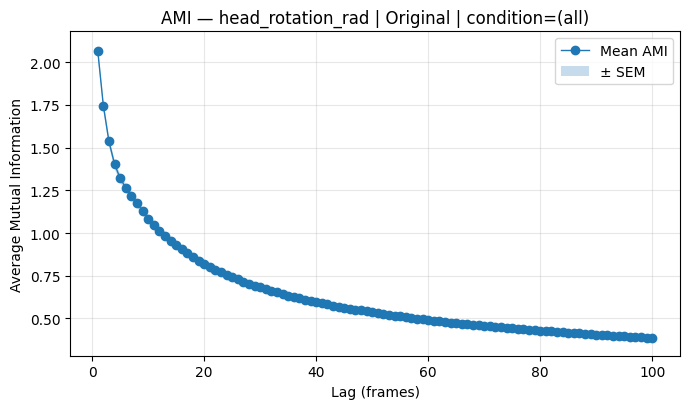

[OK] AMI curves: 216 series averaged
Counts by condition: {'H': 72, 'L': 72, 'M': 72}
Unique participants: 72


In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------- AMI ----------------
def ami(timeseries, min_lag, max_lag):
    # 1D numpy
    if isinstance(timeseries, (pd.Series, pd.DataFrame)):
        x = timeseries.values.flatten()
    elif isinstance(timeseries, np.ndarray):
        x = timeseries.flatten()
    else:
        raise ValueError("timeseries must be a NumPy array or Pandas Series/DataFrame")

    x = x[np.isfinite(x)]
    length = len(x)
    if length < 2*max_lag:
        return None  # too short for requested lags

    # lag vector
    if max_lag <= (length // 2 - 1):
        lag = np.arange(1, max_lag + 1)
    else:
        print("warning: max_lag exceeds n/2-1; setting to n/2-1")
        lag = np.arange(1, length // 2)

    # scale to [0,1] (guard against constant series)
    lo, hi = np.min(x), np.max(x)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.column_stack((lag, np.zeros_like(lag, dtype=float)))
    x = (x - lo) / (hi - lo)

    ami_values = np.zeros(len(lag), dtype=float)
    for i in tqdm(range(len(lag)), desc='Processing AMI', leave=False):
        N = length - lag[i]
        if N <= 2:
            ami_values[i] = 0.0
            continue
        k = int(np.floor(1 + np.log2(N) + 0.5))
        if k < 2 or np.var(x[:N], ddof=1) == 0:
            ami_values[i] = 0.0
            continue

        x1 = x[:N]
        x2 = x[lag[i]:]
        s = 0.0
        for k1 in range(1, k + 1):
            x1_lo, x1_hi = (k1 - 1) / k, k1 / k
            mask1 = (x1 > x1_lo) & (x1 <= x1_hi)
            if not mask1.any():
                continue
            px1 = mask1.sum() / N
            for k2 in range(1, k + 1):
                x2_lo, x2_hi = (k2 - 1) / k, k2 / k
                mask2 = (x2 > x2_lo) & (x2 <= x2_hi)
                if not mask2.any():
                    continue
                px2 = mask2.sum() / N
                pxy = (mask1 & mask2).sum() / N
                if pxy > 0:
                    s += pxy * np.log2(pxy / (px1 * px2))
        ami_values[i] = s

    return np.column_stack((lag, ami_values))

# ---------------- Params ----------------
MIN_LAG = 1
MAX_LAG = 100

# ---------------- Run AMI on selected series ----------------
if "rqa_series_list" not in globals() or not rqa_series_list:
    raise RuntimeError("No time series loaded. Run the loader cell and click 'Load series' first.")

ami_curves = []
lags_ref = None

for idx, s in enumerate(rqa_series_list):
    res = ami(s, MIN_LAG, MAX_LAG)
    if res is None or res.shape[0] == 0:
        continue
    if lags_ref is None:
        lags_ref = res[:, 0]
    if res[:, 0].shape != lags_ref.shape or not np.allclose(res[:, 0], lags_ref):
        # unexpected mismatch, skip this one
        continue
    ami_curves.append(res[:, 1])

if not ami_curves:
    raise RuntimeError("AMI produced no curves (series may be too short for chosen lags).")

ami_stack = np.vstack(ami_curves)
ami_mean  = np.nanmean(ami_stack, axis=0)
ami_sem   = np.nanstd(ami_stack, axis=0, ddof=1) / np.sqrt(ami_stack.shape[0])

plt.figure(figsize=(7,4.2))
plt.plot(lags_ref, ami_mean, marker='o', linewidth=1, label='Mean AMI')
plt.fill_between(lags_ref, ami_mean-ami_sem, ami_mean+ami_sem, alpha=0.25, label='± SEM')
plt.title(f"AMI — {selected_metric_name} | {selected_norm_label} | condition={selected_condition}")
plt.xlabel("Lag (frames)")
plt.ylabel("Average Mutual Information")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"[OK] AMI curves: {len(ami_curves)} series averaged")
if "rqa_series_metadata" in globals():
    # quick peek
    from collections import Counter
    conds = Counter([m.get("condition") for m in rqa_series_metadata])
    pids  = Counter([m.get("participant") for m in rqa_series_metadata])
    print("Counts by condition:", dict(conds))
    print("Unique participants:", len(pids))


## False Nearest Neighbors (FNN)

## AutoRQA

## Stats and Figure Outputs

# Pose Cross Recurrence Quantification Analysis

## Cross Average Mutual Information (Cross-AMI)

## Cross RQA

## Stats and Figure Outputs